In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)

Libraries loaded successfully.


In [2]:
df = pd.read_csv("../data/credit.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (1000, 21)


In [3]:
df.head()

,Creditability,Status of exsiting checking amount,Duration of Credit (month),Credit History,Purpose,Credit Amount,Savings account/bonds,Present employement since,Installment percent,Sex & Marital Status,Guarantors,Present Residence since,Property,Age (years),Other installment plans,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,1,1,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Creditability                       1000 non-null   int64
 1   Status of exsiting checking amount  1000 non-null   int64
 2   Duration of Credit (month)          1000 non-null   int64
 3   Credit History                      1000 non-null   int64
 4   Purpose                             1000 non-null   int64
 5   Credit Amount                       1000 non-null   int64
 6   Savings account/bonds               1000 non-null   int64
 7   Present employement since           1000 non-null   int64
 8   Installment percent                 1000 non-null   int64
 9   Sex & Marital Status                1000 non-null   int64
 10  Guarantors                          1000 non-null   int64
 11  Present Residence since             1000 non-null   int64
 12  Propert

In [5]:
df["Creditability"].value_counts()

Creditability
1    700
0    300
Name: count, dtype: int64

In [6]:
df["Creditability"].value_counts(normalize=True) * 100

Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64

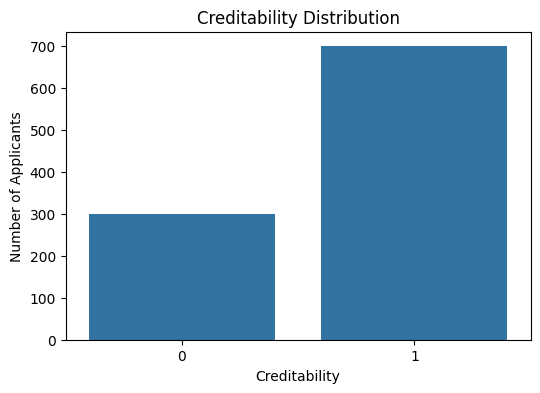

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Creditability")

plt.title("Creditability Distribution")
plt.xlabel("Creditability")
plt.ylabel("Number of Applicants")
plt.show()

In [8]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
0

Duplicate rows:
0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Creditability,1000.0,0.700,0.458487,0.0,0.0,1.0,1.00,1.0
Status of exsiting checking amount,1000.0,2.577,1.257638,1.0,1.0,2.0,4.00,4.0
Duration of Credit (month),1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Credit History,1000.0,2.545,1.083120,0.0,2.0,2.0,4.00,4.0
Purpose,1000.0,2.828,2.744439,0.0,1.0,2.0,3.00,10.0
Credit Amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
Savings account/bonds,1000.0,2.105,1.580023,1.0,1.0,1.0,3.00,5.0
Present employement since,1000.0,3.384,1.208306,1.0,3.0,3.0,5.00,5.0
Installment percent,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
Sex & Marital Status,1000.0,2.682,0.708080,1.0,2.0,3.0,3.00,4.0


In [10]:
df["Credit_Risk"] = df["Creditability"].map({
    0: "Bad",
    1: "Good"
})

df["Credit_Risk"].value_counts()

Credit_Risk
Good    700
Bad     300
Name: count, dtype: int64

In [11]:
#grouping data for simple analysis
df["Age_Group"] = pd.cut(
    df["Age (years)"],
    bins=[18, 25, 40, 60, np.inf],
    labels=["19-25", "26-40", "41-60", "60+"],
    include_lowest=True
)

df["Credit_Amount_Group"] = pd.cut(
    df["Credit Amount"],
    bins=[0, 1000, 5000, 10000, np.inf],
    labels=["<1000", "1000-5000", "5000-10000", "10000+"],
    include_lowest=True
)

df["Duration_Group"] = pd.cut(
    df["Duration of Credit (month)"],
    bins=[0, 12, 18, 24, np.inf],
    labels=["<=12", "13-18", "19-24", "25+"],
    include_lowest=True
)

In [12]:
age_risk = pd.crosstab(
    df["Age_Group"],
    df["Credit_Risk"],
    normalize="index"
) * 100

age_risk.round(2)

Credit_Risk,Bad,Good
Age_Group,,
19-25,42.11,57.89
26-40,27.51,72.49
41-60,27.31,72.69
60+,22.22,77.78


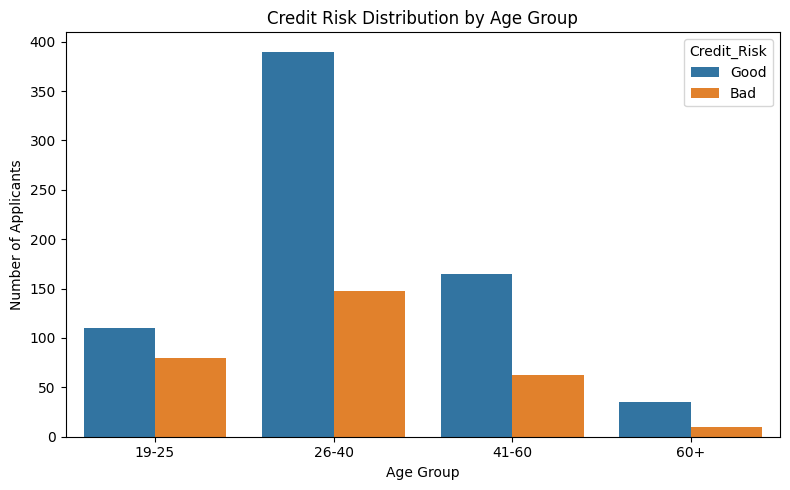

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Age_Group",
    hue="Credit_Risk"
)

plt.title("Credit Risk Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

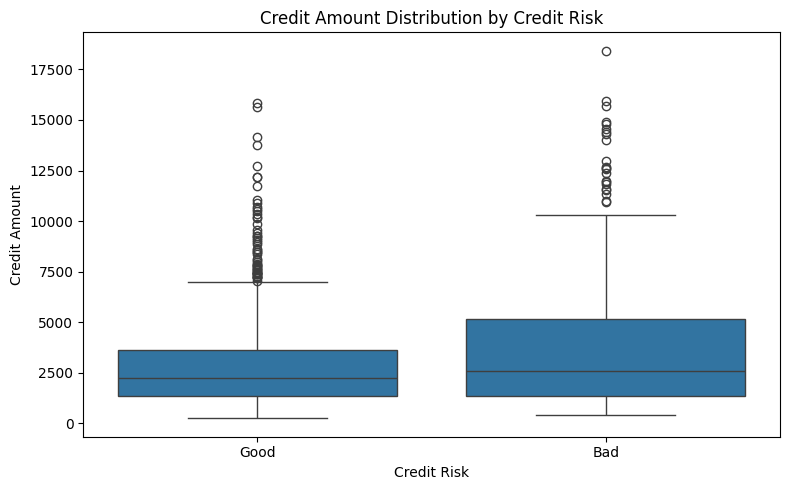

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Credit_Risk",
    y="Credit Amount"
)

plt.title("Credit Amount Distribution by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")
plt.tight_layout()
plt.show()

In [15]:
credit_risk = pd.crosstab(
    df["Credit_Amount_Group"],
    df["Credit_Risk"],
    normalize="index"
) * 100

credit_risk.round(2)

Credit_Risk,Bad,Good
Credit_Amount_Group,,
<1000,31.90,68.10
1000-5000,26.58,73.42
5000-10000,36.49,63.51
10000+,60.00,40.00


In [16]:
duration_risk = pd.crosstab(
    df["Duration_Group"],
    df["Credit_Risk"],
    normalize="index"
) * 100

duration_risk.round(2)

Credit_Risk,Bad,Good
Duration_Group,,
<=12,21.17,78.83
13-18,29.95,70.05
19-24,29.46,70.54
25+,44.35,55.65


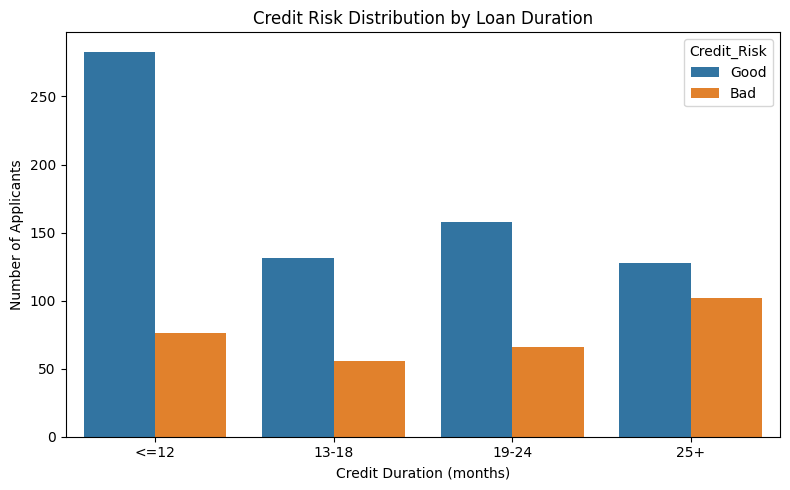

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Duration_Group",
    hue="Credit_Risk"
)

plt.title("Credit Risk Distribution by Loan Duration")
plt.xlabel("Credit Duration (months)")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

In [18]:
savings_risk = pd.crosstab(
    df["Savings account/bonds"],
    df["Credit_Risk"],
    normalize="index"
) * 100

savings_risk.round(2)

Credit_Risk,Bad,Good
Savings account/bonds,,
1,35.99,64.01
2,33.01,66.99
3,17.46,82.54
4,12.50,87.50
5,17.49,82.51


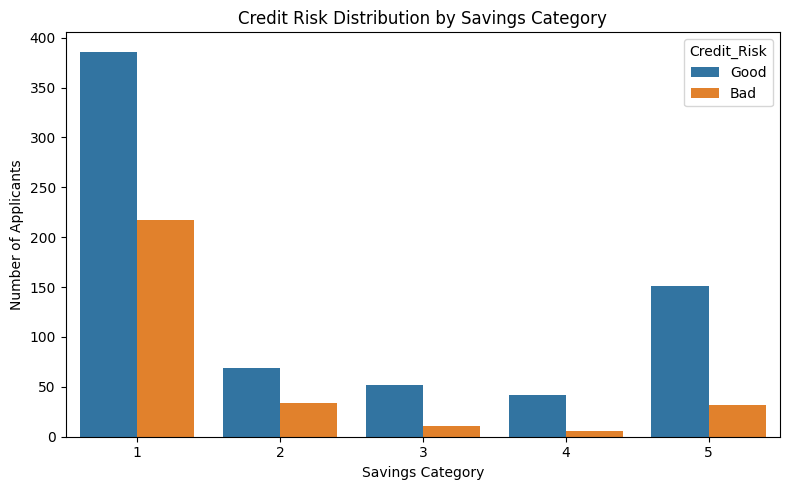

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Savings account/bonds",
    hue="Credit_Risk"
)

plt.title("Credit Risk Distribution by Savings Category")
plt.xlabel("Savings Category")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

In [20]:
occupation_risk = pd.crosstab(
    df["Occupation"],
    df["Credit_Risk"],
    normalize="index"
) * 100

occupation_risk.round(2)

Credit_Risk,Bad,Good
Occupation,,
1,31.82,68.18
2,28.00,72.00
3,29.52,70.48
4,34.46,65.54


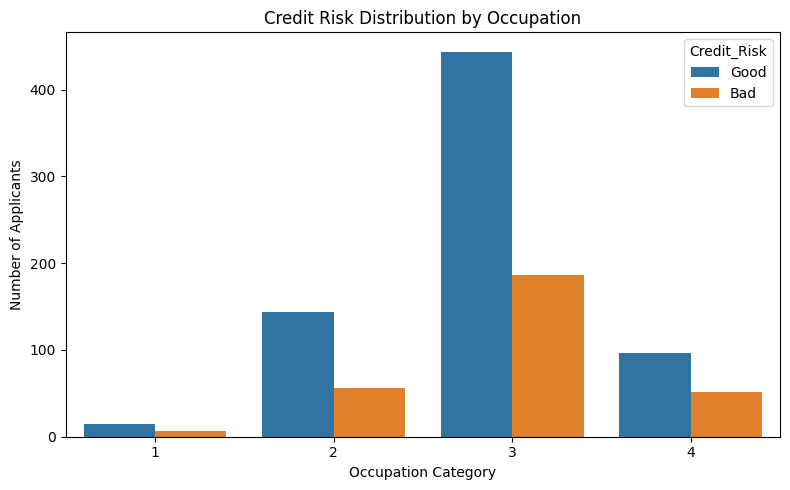

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Occupation",
    hue="Credit_Risk"
)

plt.title("Credit Risk Distribution by Occupation")
plt.xlabel("Occupation Category")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()